In [1]:
%env CUDA_VISIBLE_DEVICES=0
%load_ext autoreload
%autoreload 2

import os
import numpy as np
import matplotlib.pyplot as plt

import sys
sys.path.append("/gpfs01/berens/user/sdamrich/mirrored_code/cl_neuro/contrastive_learning_neuro")
from timeseries_data import load_data_sc
from sc_utils import compute_discriminability

import seaborn as sns
import matplotlib as mpl
from matplotlib.colors import ListedColormap
from matplotlib.colors import LinearSegmentedColormap
import matplotlib.patheffects


import pandas as pd




env: CUDA_VISIBLE_DEVICES=0


In [2]:
fig_path = "/gpfs01/berens/user/sdamrich/data/cl_neuro/figures"
results_path = "/gpfs01/berens/user/sdamrich/data/cl_neuro/ts2vec"


# our toy data

In [3]:
toy_path = "/gpfs01/berens/data/data/superior_colliculus/toy_data/"
labels = np.load(os.path.join(toy_path, "toy_data_labels.npy"))


hparams = {
    "default": {"n_epochs": None, "batch_size": 16, "similarity": "cosine"},
    "adapted": {"n_epochs": 1000, "batch_size": 1024, "similarity": "cauchy"}
           }
basenoise_SDs = [1, 2, 4, 6, 10, 15, 20, 24, 38, 60]
seeds = [0, 1, 2]

In [4]:

# load all embeddings and compute discriminablities
res_dict = {}
for setting, hparam in hparams.items():
    embds = []
    discrs = []
    for basenoise_SD in basenoise_SDs:
        embds_by_seed = []
        discrs_by_seed = []
        for seed in seeds:
            file_name = f"toy_data_basenoiseSD_{basenoise_SD}_ts2vec_epochs_{hparam['n_epochs']}_bs_{hparam['batch_size']}_sim_{hparam['similarity']}_seed_{seed}_embd.npy"
            try:
                embd = np.load(os.path.join(results_path,file_name ))
                discr = compute_discriminability(embd, labels, class1=1, class2=2)
            except:
                print(file_name)
                continue
            embds_by_seed.append(embd)
            discrs_by_seed.append(discr)
        embds.append(embds_by_seed)
        discrs.append(discrs_by_seed)

    res_dict[setting] = {"embds": np.moveaxis(np.stack(embds), 0 ,1), "discrs": np.stack(discrs).T}


# save discriminabilities
cols = basenoise_SDs
rows = np.array([0, 1, 2])
for setting, hparam in hparams.items():
    df = pd.DataFrame(res_dict[setting]["discrs"], columns=cols, index=rows)
    df.to_csv(os.path.join(results_path, f"toy_data_basenoiseSDs_ts2vec_epochs_{hparam['n_epochs']}_bs_{hparam['batch_size']}_sim_{hparam['similarity']}_discrs.csv"))


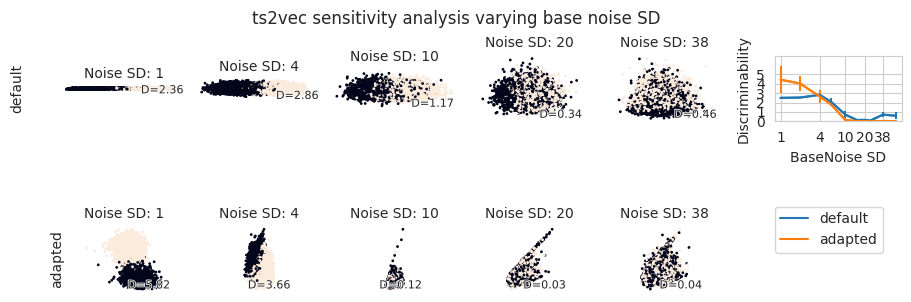

In [5]:
# plot figure with example embeddings and discriminability curves
fig, ax = plt.subplots(2, 6, figsize=(9, 3), constrained_layout=True)

p_eff = [
                mpl.patheffects.withStroke(linewidth=1.1, foreground="white")
            ]
plot_order = np.random.permutation(embd.shape[0])

for i, (setting, res) in enumerate(res_dict.items()):

    # plot example embeddings
    for j, (embd, discr) in enumerate(zip(res["embds"][0], res["discrs"][0])):
        plot_embd = embd[plot_order][:, ::-1]

        if j % 2 == 1 or j > 8:
            continue
        else:
            c = j//2
        ax[i, c].scatter(*plot_embd.T, c=labels[plot_order], s=1)
        ax[i, c].set_title(f"Noise SD: {basenoise_SDs[j]}", fontsize=10)
        ax[i, c].axis("off")
        ax[i, c].set_aspect("equal")
        ax[i, c].text(s=f"D={float(discr):.2f}", x=0.8, y=0.1, ha="center", transform=ax[i, c].transAxes, va="center", fontsize=8, path_effects=p_eff)

        if j==0:
            ax[i, c].text(x=-0.4, y=0.5, va="center", transform=ax[i, c].transAxes, s=setting, rotation="vertical", fontsize=10)

    # plot discriminability curves
    mean_discr = np.mean(res["discrs"], axis=0)
    std_discr = np.std(res["discrs"], axis=0)

    line, = ax[0, -1].plot(basenoise_SDs, mean_discr, label=setting)
    ax[0, -1].errorbar(basenoise_SDs, mean_discr, yerr=std_discr, c=line.get_color() )



    ax[0, -1].set_xlabel("BaseNoise SD")
    ax[0, -1].set_ylabel("Discriminability")
    ax[0, -1].set_yticks(np.arange(6))
    ax[0, -1].set_xscale("log")
    ax[0, -1].set_xticks(basenoise_SDs[::2])
    ax[0, -1].set_xticklabels(basenoise_SDs[::2])
    ax[0, -1].tick_params(axis='x', which='minor', bottom=False)  # Disable minor ticks on x-axis
    ax[0, -1].set_ylim(0, 7)
    ax[0, -1].legend(loc=(0, -2))

ax[-1, -1].axis("off")
fig.suptitle("ts2vec sensitivity analysis varying base noise SD")
fig.savefig(os.path.join(fig_path, "ts2vec_sensitivity_analysis_base_noise.png"), dpi=300)

In [6]:
# print discriminabilities for tables
discr = res_dict["adapted"]["discrs"]
mean_discr = np.mean(res["discrs"], axis=0)
std_discr = np.std(res["discrs"], axis=0)

for j, noise_SD in enumerate(basenoise_SDs):
    print(f"Noise SD: {noise_SD}")
    print(f"mean discr: {mean_discr[j]:.2f} +/- std discr: {std_discr[j]:.2f}")

Noise SD: 1
mean discr: 4.43 +/- std discr: 1.46
Noise SD: 2
mean discr: 4.03 +/- std discr: 0.77
Noise SD: 4
mean discr: 2.65 +/- std discr: 0.71
Noise SD: 6
mean discr: 1.79 +/- std discr: 0.03
Noise SD: 10
mean discr: 0.13 +/- std discr: 0.01
Noise SD: 15
mean discr: 0.03 +/- std discr: 0.01
Noise SD: 20
mean discr: 0.03 +/- std discr: 0.00
Noise SD: 24
mean discr: 0.01 +/- std discr: 0.00
Noise SD: 38
mean discr: 0.03 +/- std discr: 0.00
Noise SD: 60
mean discr: 0.02 +/- std discr: 0.01


# SC data

In [7]:
labels4 = np.load(os.path.join("/gpfs01/berens/data/data/superior_colliculus", "labels_bar.npy"))
data = load_data_sc(flatten_bar=False)
idx_arti = np.load(os.path.join(results_path, "idx_artifact_cluster.npy"))  # indices of known light artifact cluster


In [8]:
n_clusters = 50
cmap = ListedColormap(sns.husl_palette(n_clusters).as_hex())


colors = ['steelblue', 'turquoise', 'mediumseagreen', 'black']
n_bin = 4
cmap4 = LinearSegmentedColormap.from_list('cmap', colors, N=n_bin)

## default setting

In [10]:
file_name_default = f"sc_dat_ts2vec_epochs_None_bs_16_sim_cosine_seed_0_embd.npy"
embd_default = np.load(os.path.join(results_path,file_name_default))

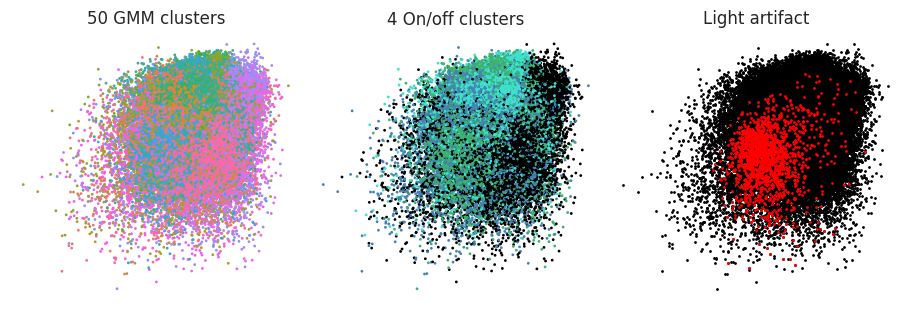

In [11]:
# plot embedding with three colorings
fig, ax = plt.subplots(1, 3, figsize=(9, 3), constrained_layout=True)


ax[0].scatter(*embd_default.T, c=data[2], cmap=cmap, s=1)
ax[0].axis("off")
ax[0].set_title("50 GMM clusters")


ax[1].scatter(*embd_default.T, c=labels4, cmap=cmap4, s=1)
ax[1].axis("off")
ax[1].set_title("4 On/off clusters")

ax[2].scatter(*embd_default.T, c="k", s=1)
ax[2].scatter(*embd_default[idx_arti].T, c="r", s=1)

ax[2].axis("off")
ax[2].set_title("Light artifact")

fig.savefig(os.path.join(fig_path, "ts2vec_default_sc_flattened_bar.png"), dpi=300)

## adapted setting

In [12]:
file_name_adapted = f"sc_dat_ts2vec_epochs_1000_bs_768_sim_cauchy_seed_0_embd.npy"
embd_adapted = np.load(os.path.join(results_path,file_name_adapted))

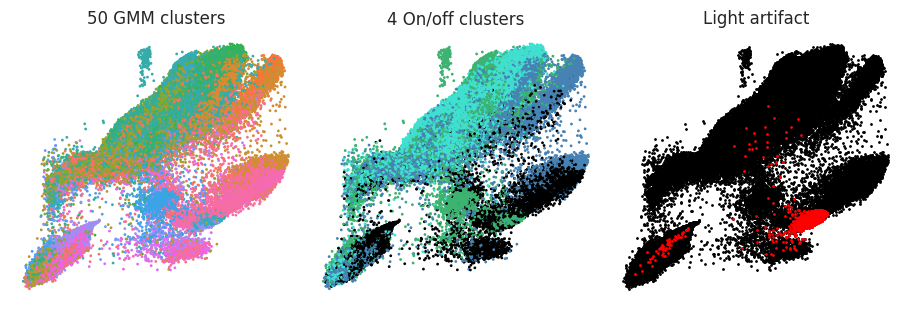

In [13]:
# plot embedding with three colorings
fig, ax = plt.subplots(1, 3, figsize=(9, 3), constrained_layout=True)


ax[0].scatter(*embd_adapted.T, c=data[2], cmap=cmap, s=1)
ax[0].axis("off")
ax[0].set_title("50 GMM clusters")


ax[1].scatter(*embd_adapted.T, c=labels4, cmap=cmap4, s=1)
ax[1].axis("off")
ax[1].set_title("4 On/off clusters")

ax[2].scatter(*embd_adapted.T, c="k", s=1)
ax[2].scatter(*embd_adapted[idx_arti].T, c="r", s=1)

ax[2].axis("off")
ax[2].set_title("Light artifact")

fig.savefig(os.path.join(fig_path, "ts2vec_adapted_sc_flattened_bar.png"), dpi=300)